In [1]:
from langgraph.graph import StateGraph, START, END
from spm_agent.states.pfm_experiment_state import PFMExperimentState
from spm_agent.nodes.full_exp_analysis_node import full_exp_analysis_node
from spm_agent.nodes.decision_node import experiment_decision_node

import numpy as np

In [2]:
MOCK_SCAN_FILE = r"/Users/borisslautin/Documents/!!UTK/agentic_SPM/exp_files/PLZT_0001.ibw"

MOCK_LOOP_FILE = r"/Users/borisslautin/Downloads/PLZT/PLZT_0005.ibw"


In [3]:
def route_by_decision(state: PFMExperimentState) -> str:
    return state["decision_records"][-1].action

In [4]:
async def mock_pick_node(state):                          # placeholder for pick_point_node
    scan = [r for r in state["experimental_records"] if r["kind"] == "image"][-1]
    m = np.load(scan["importance_maps"][0]["importance_map_path"])
    yx = tuple(int(v) for v in np.unravel_index(int(np.argmax(m)), m.shape))
    return {"pending": {**state["pending"], "pixel_yx": yx}}


async def acquire_loop_node(state):                       # stub -> real microscope later
    return {"pending": {**state["pending"], "file_path": MOCK_LOOP_FILE}}

async def acquire_scan_node(state):                      # stub -> real microscope later
    return {"pending": {**state["pending"], "file_path": MOCK_SCAN_FILE}}

In [5]:
g = StateGraph(PFMExperimentState)
g.add_node("acquire_scan", acquire_scan_node)
g.add_node("analysis", full_exp_analysis_node)
g.add_node("decide", experiment_decision_node)
g.add_node("pick_point", mock_pick_node)
g.add_node("acquire_loop", acquire_loop_node)

g.add_edge(START, "decide")
g.add_conditional_edges("decide", route_by_decision,
                        {"scan": "acquire_scan",
                         "loop": "pick_point",
                         "stop": END})

g.add_edge("acquire_scan", "analysis")
g.add_edge("pick_point", "acquire_loop")
g.add_edge("acquire_loop", "analysis")
g.add_edge("analysis", "decide")

fin_gr = g.compile()

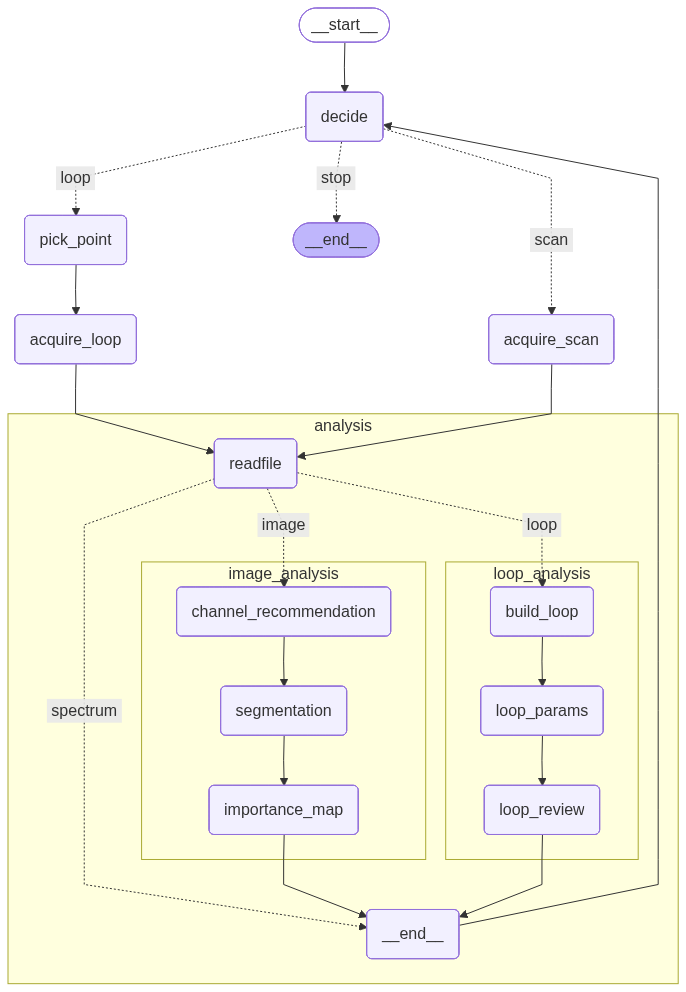

In [6]:
from IPython.display import Image
Image(fin_gr.get_graph(xray=True).draw_mermaid_png())

In [7]:
from spm_agent.config import new_run
run_path = new_run("")
print(run_path)

/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/runs/20260716_161158


In [8]:
EXPERIMENT_TASKS = [
    # "Select a diverse measurement set",
    # "Map switching asymmetry across opposite domains",
    "Compare switching inside domains vs near domain walls",
    # "Study wall-mediated switching"
    # "Investigate the role of domain walls in polarization switching",
    # "Characterize the spatial heterogeneity of switching behavior",
    # "Identify the microstructural origins of switching asymmetry",
    # "Determine the most informative locations for testing competing switching mechanisms",
]

EXPERIMENT_CONTEXT = (
        "This is Dual AC Resonance Tracking (DART) PFM experiment: two drive frequencies f1 and f2 straddle the "
        "contact resonance.  "
)

In [9]:
res = await fin_gr.ainvoke(
    {"experiment_tasks": EXPERIMENT_TASKS,
     "experiment_context": EXPERIMENT_CONTEXT},
    config={"recursion_limit": 60},
)

image
loop
loop
loop


In [11]:
res

{'experiment_tasks': ['Compare switching inside domains vs near domain walls'],
 'experiment_context': 'This is Dual AC Resonance Tracking (DART) PFM experiment: two drive frequencies f1 and f2 straddle the contact resonance.  ',
 'experimental_records': [{'file_path': '/Users/borisslautin/Documents/!!UTK/agentic_SPM/exp_files/PLZT_0001.ibw',
   'file_channels': {'Channel_000': {'title': 'HeightRetrace',
     'units': 'm',
     'data_type': 'IMAGE',
     'shape': [256, 256],
     'stats': {'ok': True,
      'min': -4.108699158678064e-09,
      'max': 6.594916612812085e-09,
      'mean': -8.413408858487514e-17,
      'std': 1.868449575889247e-09,
      'p01': -2.8537556318042336e-09,
      'p99': 4.834470246350975e-09},
     'preview_path': '/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/spm_agent/.cashe/current/HeightRetrace.png',
     'array_path': '/Users/borisslautin/Documents/GitHub/SPM_agent_simple/src/spm_agent/.cashe/current/HeightRetrace.npy'},
    'Channel_001': {'t